In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('car20240731.csv')

In [13]:
#from sklearn import datasets

In [14]:
#iris=datasets.load_iris()

In [12]:
df.head()

,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
1,볼보,볼보 XC60T8 AWD,전기+휘발유,자동,PHEV,승용차,16.6,17.1,33.0,61.0,1969.0,PHEV,2024
2,벤츠,Mercedes-Benz GLC 220 d 4MATIC,경유,자동,하이브리드,승용차,13.8,15.5,130.0,NaN,1993.0,2등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
4,랜드로버,더 뉴 레인지로버 P550e SWB,전기+휘발유,자동,PHEV,승용차,11.5,13.1,35.0,80.0,2996.0,PHEV,2024


In [20]:
print(df.shape)

(3498, 13)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3498 non-null   object 
 1   모델명           3498 non-null   object 
 2   연료            3498 non-null   object 
 3   변속형식          3498 non-null   object 
 4   차량형식          3498 non-null   object 
 5   자동차 종류        3498 non-null   object 
 6   도심주행연비        3497 non-null   float64
 7   고속도로연비        3497 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  403 non-null    float64
 10  배기량           3187 non-null   float64
 11  등급            3498 non-null   object 
 12  출시연도          3498 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 355.4+ KB


In [26]:
df[['배기량', '고속도로연비', 'CO2배출량(g_km)']].describe()

,배기량,고속도로연비,CO2배출량(g_km)
count,3187.000000,3497.000000,3186.000000
mean,2557.875118,11.752617,168.908035
std,965.196309,4.508477,48.694492
min,0.000000,0.000000,14.000000
25%,1995.000000,9.800000,137.000000
50%,2199.000000,11.800000,167.000000
75%,2997.000000,14.100000,199.000000
max,6749.000000,92.600000,354.000000


In [29]:
#배기량이 0인 이상치를 날리고 df에 그대로 덮어쓴 것
df = df[df['배기량'] > 0]

In [30]:
print('전처리 후:', df.shape)

전처리 후: (3186, 13)


In [32]:
#이상치를 제거해 더 신뢰할 수 있게 바꾼 통계
df[['배기량', 'CO2배출량(g_km)']].describe()

,배기량,CO2배출량(g_km)
count,3186.000000,3186.000000
mean,2558.677966,168.908035
std,964.282913,48.694492
min,796.000000,14.000000
25%,1995.000000,137.000000
50%,2199.000000,167.000000
75%,2997.000000,199.000000
max,6749.000000,354.000000


In [33]:
df1 = df[df['연료'] == '휘발유']
df2 = df[df['연료'] == '경유']

In [35]:
print('휘발유:', df1.shape)
print('경유', df2.shape)

휘발유: (1997, 13)
경유 (972, 13)


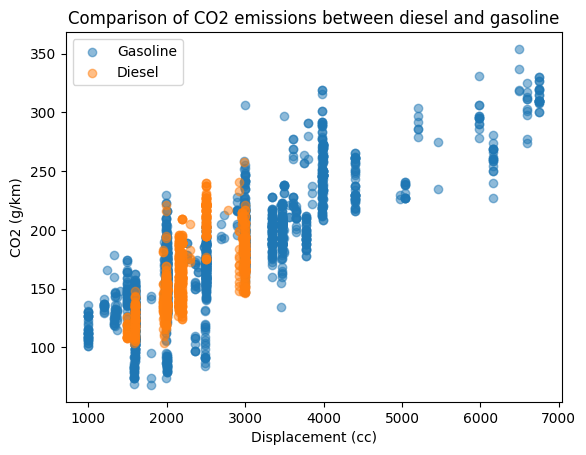

In [37]:
#산점도 그래프가 상관계 파악에 가장 좋음
plt.scatter(df1['배기량'], df1['CO2배출량(g_km)'], alpha=0.5, label='Gasoline')
plt.scatter(df2['배기량'], df2['CO2배출량(g_km)'], alpha=0.5, label='Diesel')
plt.xlabel('Displacement (cc)')
plt.ylabel('CO2 (g/km)')
plt.title('Comparison of CO2 emissions between diesel and gasoline')
plt.legend()
plt.show()

In [39]:
#corr로 상관관계 계수 보기
r1 = df1['배기량'].corr(df1['CO2배출량(g_km)'])
r2 = df2['배기량'].corr(df2['CO2배출량(g_km)'])

print(f'휘발유 차량 상관계수: {r1:.3f}')
print(f'경유  차량 상관계수: {r2:.3f}')

휘발유 차량 상관계수: 0.856
경유  차량 상관계수: 0.656


In [ ]:
지도학습:정답이 정해져있는거 비지도학습: 정답이 없는
지도는 다시 분류와 회귀/범주형: 정답이 범주형(맞다아니다 판단), 회귀형: 정답이 연속값(오르내림)
지도는 정답을 제공해주니 빠르고 적은 자료로도 가능함
비지도는 정답을 제공하지 않고 직접하게 시키니 오래 걸리고 데이터가 많이 필요
절차는 데이터수집-전처리-모델생성(알고리즘 학습)-모델 평가/실제론 수집이 젤 어렵고 오래걸리고 전처리가 젤 복잡
ㄴ전처리때 결측치 없애고 훈련세트와 테스트 세트로 나눠 훈련세트로 모델생성, 테스트세트로 모델평가를 함(보통 7대3 8대2로 나눔)


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
#데이터 수집
from sklearn import datasets   #싸이킬런에 있는 예제 데이터들을 가져오는 것. iris 말고도 wine 등 다양하게 있음
iris = datasets.load_iris()
df_iris = pd.read_csv('Iris.csv')   #파일 가져와서 데이터프레임 만드는게 일반적인 방식이긴 함/데이터 구조도 좀 달라

In [58]:
print('iris 키:', iris.keys())

iris 키: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [53]:
print('데이터:\n',iris['data'][:5])

데이터:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [61]:
print('특성이름:', iris['feature_names'])   #판단에 쓸 속성

특성이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [52]:
print('타깃:\n', iris['target'][:5])

타깃:
 [0 0 0 0 0]


In [54]:
print('타킷이름:', iris['target_names'])

타킷이름: ['setosa' 'versicolor' 'virginica']


In [57]:
print('데이터 크기:', iris['data'].shape)
print('타킷 크기:', iris['target'].shape)

데이터 크기: (150, 4)
타킷 크기: (150,)


In [65]:
#데이터 전처리(훈련세트 테스트세트 나누는 과정)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'],\
random_state=0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(112, 4) (112,)
(38, 4) (38,)


In [70]:
#모델 생성하기
from sklearn.neighbors import KNeighborsClassifier
KNeighborsClassifier(n_neighbors=int(input('이웃 개수를 입력해주세요')))

이웃 개수를 입력해주세요 3


KNeighborsClassifier(n_neighbors=3)

In [73]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

In [74]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [89]:
print(iris['target_names'][pred])

NameError: name 'pred' is not defined

In [90]:
y_pred = knn.predict(X_test)
print('테스트 세트 예측 값:\n',y_pred)
print('테스트 세트 실제 타킷:\n', y_test)

테스트 세트 예측 값:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
테스트 세트 실제 타킷:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]


In [91]:
#모델평가하기 
print(f'훈련 세트 정확도: {knn.score(X_train, y_train):.3f}')
print(f'테스트 세트 정확도: {knn.score(X_test, y_test):.3f}')

훈련 세트 정확도: 0.964
테스트 세트 정확도: 0.974


In [92]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

#수집
wine = datasets.load_wine()
print('wine 키:', wine.keys())
print('데이터:\n', wine['data'][:5])
print('특성 이름:', wine['feature_names'])
print('타킷:\n', wine['target'][:5])
print('특성 이름:', wine['target_names'])
print('데이터 크기:', wine['data'].shape)
print('타킷 크기:', wine['target'].shape)

#전처리
X_train, X_test, y_train, y_test = train_test_split(wine['data'], wine['target'],\
random_state=0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

#모델 생성하기
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

#모델 이용 예측하기
y_pred = knn.predict(X_test)
print('테스트 세트 예측 값:\n',y_pred)
print('테스트 세트 실제 타킷:\n', y_test)

#모델평가하기
print(f'훈련 세트 정확도: {knn.score(X_train, y_train):.3f}')
print(f'테스트 세트 정확도: {knn.score(X_test, y_test):.3f}')

wine 키: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])
데이터:
 [[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]
특성 이름: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
타킷:
 [0 0 0 